# Twitter Named Entity Recognition (NER)

## Problem Statement
Twitter wants to automatically tag and analyze tweets for better understanding of trends and topics without relying on hashtags. We need to train models to identify named entities such as person, geo-location, company, facility, product, music artist, movie, sports team, tv show, and others.

## Process
1. Data Import & Exploratory Analysis
2. Data Preprocessing
3. LSTM + CRF Model Training
4. Transformer (BERT) Model Training
5. Evaluation & Q&A

In [1]:
import sys
import warnings
import os

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow info messages

# Attempt to install dependencies if missing
print("Installing dependencies (if needed)...")
try:
    import tensorflow
except ImportError:
    !{sys.executable} -m pip install tensorflow

!{sys.executable} -m pip install transformers seqeval scikit-learn pandas
# Optional dependencies
!{sys.executable} -m pip install matplotlib seaborn gensim

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

print(f"TensorFlow Version: {tf.__version__}")

Installing dependencies (if needed)...
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
TensorFlow Version: 2.20.0


## 1. Import Data and Understand Structure

In [2]:
train_file_path = 'wnut 16.txt.conll'
test_file_path = 'wnut 16test.txt.conll'

def load_conll(file_path):
    sentences = []
    labels = []
    
    current_sentence = []
    current_labels = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_sentence:
                    sentences.append(current_sentence)
                    labels.append(current_labels)
                    current_sentence = []
                    current_labels = []
            else:
                parts = line.split()
                # Handle cases where whitespace might be weird, usually last is label
                word = line.split()[0]
                label = line.split()[-1]
                current_sentence.append(word)
                current_labels.append(label)
        
        # Add last sentence if exists
        if current_sentence:
            sentences.append(current_sentence)
            labels.append(current_labels)
            
    return sentences, labels

train_sentences, train_labels = load_conll(train_file_path)
test_sentences, test_labels = load_conll(test_file_path)

print(f"Train Data: {len(train_sentences)} sentences")
print(f"Test Data: {len(test_sentences)} sentences")

Train Data: 2394 sentences
Test Data: 3850 sentences


In [3]:
# Inspect a few samples
for i in range(3):
    print(f"Sentence {i}: {train_sentences[i]}")
    print(f"Labels {i}: {train_labels[i]}")
    print("-"*20)

Sentence 0: ['@SammieLynnsMom', '@tg10781', 'they', 'will', 'be', 'all', 'done', 'by', 'Sunday', 'trust', 'me', '*wink*']
Labels 0: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
--------------------
Sentence 1: ['Made', 'it', 'back', 'home', 'to', 'GA', '.', 'It', 'sucks', 'not', 'to', 'be', 'at', 'Disney', 'world', ',', 'but', 'its', 'good', 'to', 'be', 'home', '.', 'Time', 'to', 'start', 'planning', 'the', 'next', 'Disney', 'World', 'trip', '.']
Labels 1: ['O', 'O', 'O', 'O', 'O', 'B-geo-loc', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-facility', 'I-facility', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-facility', 'I-facility', 'O', 'O']
--------------------
Sentence 2: ["'", 'Breaking', 'Dawn', "'", 'Returns', 'to', 'Vancouver', 'on', 'January', '11th', 'http://bit.ly/dbDMs8']
Labels 2: ['O', 'B-movie', 'I-movie', 'O', 'O', 'O', 'B-geo-loc', 'O', 'O', 'O', 'O']
--------------------


### Exploratory Data Analysis

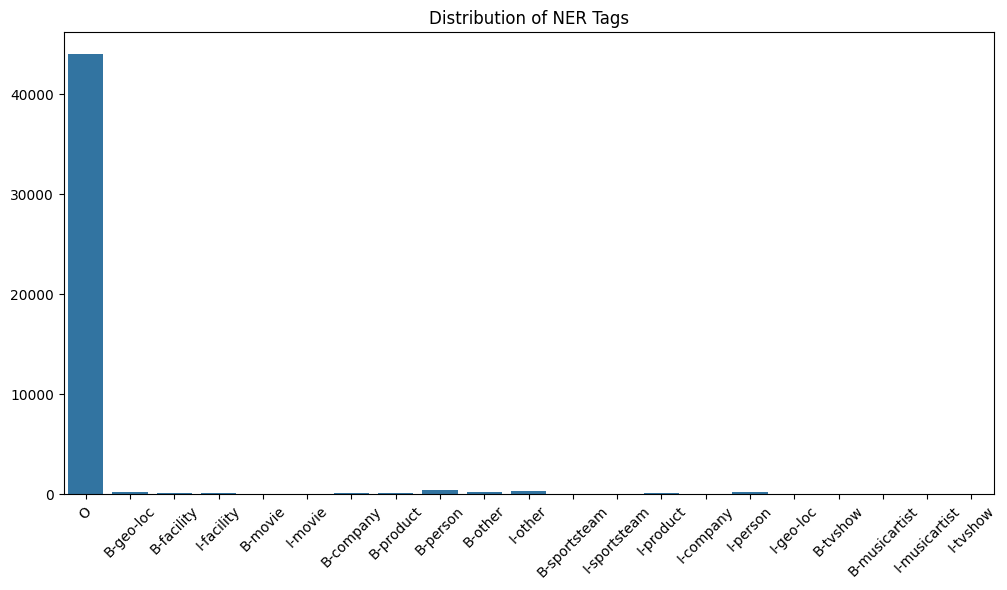

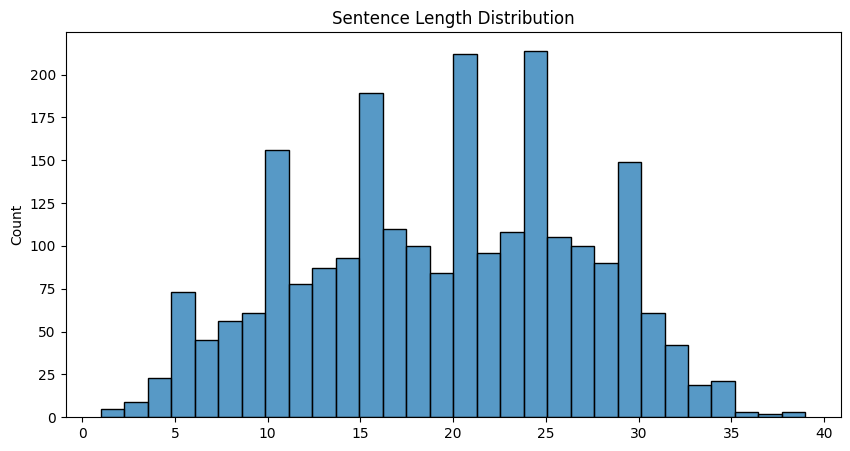

In [4]:
from collections import Counter

try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Flatten labels to see distribution
    all_labels = [label for sen_labels in train_labels for label in sen_labels]
    label_counts = Counter(all_labels)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
    plt.xticks(rotation=45)
    plt.title('Distribution of NER Tags')
    plt.show()

    # Sentence Length Distribution
    sen_lengths = [len(s) for s in train_sentences]
    plt.figure(figsize=(10, 5))
    sns.histplot(sen_lengths, bins=30)
    plt.title('Sentence Length Distribution')
    plt.show()
except ImportError:
    print("Matplotlib or Seaborn not found. Skipping visualization.")
except Exception as e:
    print(f"Plotting error: {e}")

## 2. LSTM + CRF Model

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
# Flatten labels to ensure all are captured
all_labels = [label for sen_labels in train_labels for label in sen_labels]

# Max Sequence Length
MAX_LEN = 120 # Cover most tweets

# Word Tokenizer
word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(train_sentences)
word_index = word_tokenizer.word_index
vocab_size = len(word_index) + 1

# Label Mapping
unique_labels = sorted(list(set(all_labels)))
tag2idx = {t: i for i, t in enumerate(unique_labels)}
idx2tag = {i: t for t, i in tag2idx.items()}
num_tags = len(unique_labels)

print(f"Vocab Size: {vocab_size}")
print(f"Num Tags: {num_tags}")
print(tag2idx)

Vocab Size: 9069
Num Tags: 21
{'B-company': 0, 'B-facility': 1, 'B-geo-loc': 2, 'B-movie': 3, 'B-musicartist': 4, 'B-other': 5, 'B-person': 6, 'B-product': 7, 'B-sportsteam': 8, 'B-tvshow': 9, 'I-company': 10, 'I-facility': 11, 'I-geo-loc': 12, 'I-movie': 13, 'I-musicartist': 14, 'I-other': 15, 'I-person': 16, 'I-product': 17, 'I-sportsteam': 18, 'I-tvshow': 19, 'O': 20}


In [6]:
# Padding and Encoding
X_train = word_tokenizer.texts_to_sequences(train_sentences)
X_test = word_tokenizer.texts_to_sequences(test_sentences)

X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post')
X_test = pad_sequences(X_test, maxlen=MAX_LEN, padding='post')

def encode_tags(tags, tag2idx, max_len):
    encoded = [[tag2idx[t] for t in s] for s in tags]
    return pad_sequences(encoded, maxlen=max_len, padding='post', value=tag2idx['O'])

y_train = encode_tags(train_labels, tag2idx, MAX_LEN)
y_test = encode_tags(test_labels, tag2idx, MAX_LEN)

# One-hot encode labels for LSTM
y_train_cat = to_categorical(y_train, num_tags)
y_test_cat = to_categorical(y_test, num_tags)

In [7]:
# Initialize Embeddings with Word2Vec
embedding_matrix = np.zeros((vocab_size, 100))

try:
    import gensim
    import gensim.downloader as api

    print("Training Word2Vec model...")
    # Train Word2Vec on our corpus
    w2v_model = gensim.models.Word2Vec(sentences=train_sentences, vector_size=100, window=5, min_count=1)
    
    for word, i in word_tokenizer.word_index.items():
        if word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]
        else:
            # Initialize random for unknown words
            embedding_matrix[i] = np.random.normal(0, 1, 100)
            
    print("Word2Vec embeddings created successfully.")
    
except ImportError:
    print("Gensim not found or failed to load. Using random embeddings.")
    embedding_matrix = np.random.normal(0, 1, (vocab_size, 100))
except Exception as e:
    print(f"Word2Vec training failed ({e}). Using random embeddings.")
    embedding_matrix = np.random.normal(0, 1, (vocab_size, 100))

Training Word2Vec model...
Word2Vec embeddings created successfully.


In [8]:
# LSTM Model Definition
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, TimeDistributed, Dropout, Bidirectional

input_layer = Input(shape=(MAX_LEN,))
# Removed deprecated input_length parameter
embedding_layer = Embedding(vocab_size, 100, weights=[embedding_matrix], trainable=True)(input_layer)
x = Bidirectional(LSTM(64, return_sequences=True))(embedding_layer)
x = Dropout(0.5)(x)
x = TimeDistributed(Dense(64, activation="relu"))(x)
output_layer = TimeDistributed(Dense(num_tags, activation="softmax"))(x)

model_lstm = Model(input_layer, output_layer)
model_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_lstm.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 120, 100)       │       906,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 120, 128)       │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 120, 64)        │         8,256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 120, 21)        │         1,365 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,001,001 (3.82 MB)

 Trainable params: 1,001,001 (3.82 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Training
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_lstm.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=5,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.9769 - loss: 0.2741 - val_accuracy: 0.9871 - val_loss: 0.1016
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9914 - loss: 0.0557 - val_accuracy: 0.9871 - val_loss: 0.1011
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9914 - loss: 0.0511 - val_accuracy: 0.9871 - val_loss: 0.1067
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9914 - loss: 0.0475 - val_accuracy: 0.9871 - val_loss: 0.1097
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9914 - loss: 0.0442 - val_accuracy: 0.9871 - val_loss: 0.1134


In [10]:
# Evaluation
loss, accuracy = model_lstm.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {accuracy}")

def predict_custom_sentence(sentence, model, tokenizer, idx2tag, max_len):
    words = sentence.split()
    seq = tokenizer.texts_to_sequences([words])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')
    pred = model.predict(padded, verbose=0)
    pred_idx = np.argmax(pred, axis=-1)[0]
    
    print("Token | Predicted Label")
    print("--- | ---")
    for w, p in zip(words, pred_idx):
        print(f"{w} | {idx2tag[p]}")


predict_custom_sentence("Harry Potter was a student living in london", model_lstm, word_tokenizer, idx2tag, MAX_LEN)
predict_custom_sentence("Albus Dumbledore went to the Disney World", model_lstm, word_tokenizer, idx2tag, MAX_LEN)

121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9871 - loss: 0.1011
Test Accuracy: 0.9871104955673218
Token | Predicted Label
--- | ---
Harry | O
Potter | O
was | O
a | O
student | O
living | O
in | O
london | O
Token | Predicted Label
--- | ---
Albus | O
Dumbledore | O
went | O
to | O
the | O
Disney | O
World | O


## 3. Transformer (BERT) Model

In [11]:
from transformers import BertTokenizerFast, TFBertForTokenClassification
from transformers import logging as hf_logging

# Suppress transformers warnings
hf_logging.set_verbosity_error()

print("Loading BERT tokenizer (Fast)...")
# Using Fast Tokenizer is CRITICAL for using the word_ids() method easily
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

# Align labels with BERT tokens (subwords)
def tokenize_and_align_labels(sentences, labels, tokenizer):
    tokenized_inputs = tokenizer(
        sentences,
        padding=True,
        truncation=True,
        is_split_into_words=True,
        return_tensors="tf"
    )
    
    label_ids = []
    for i, label in enumerate(labels):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids_sentence = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids_sentence.append(-100) # Special tokens
            elif word_idx != previous_word_idx:
                # Only label the first token of a given word.
                label_ids_sentence.append(tag2idx.get(label[word_idx], 0))
            else:
                label_ids_sentence.append(-100) # Subword tokens
            previous_word_idx = word_idx
        label_ids.append(label_ids_sentence)
        
    return tokenized_inputs, np.array(label_ids)



Loading BERT tokenizer (Fast)...


In [12]:
# Prepare data for BERT
print("Tokenizing data for BERT...")
tokenized_data, bert_labels = tokenize_and_align_labels(train_sentences, train_labels, tokenizer)
val_tokenized_data, val_bert_labels = tokenize_and_align_labels(test_sentences, test_labels, tokenizer)

# Convert to TF Dataset
def map_example_to_dict(input_ids, attention_masks, token_type_ids, label):
    return {
        "input_ids": input_ids,
        "token_type_ids": token_type_ids,
        "attention_mask": attention_masks,
    }, label

train_dataset = tf.data.Dataset.from_tensor_slices((
    tokenized_data['input_ids'],
    tokenized_data['attention_mask'],
    tokenized_data['token_type_ids'],
    bert_labels
))
train_dataset = train_dataset.map(map_example_to_dict).batch(16)

val_dataset = tf.data.Dataset.from_tensor_slices((
    val_tokenized_data['input_ids'],
    val_tokenized_data['attention_mask'],
    val_tokenized_data['token_type_ids'],
    val_bert_labels
))
val_dataset = val_dataset.map(map_example_to_dict).batch(16)
print("Datasets ready.")

Tokenizing data for BERT...
Datasets ready.


In [13]:
# Load Model
print("Loading BERT Model...")
model_bert = TFBertForTokenClassification.from_pretrained(
    'bert-base-uncased', 
    num_labels=num_tags,
    use_safetensors=False
)

# IMPORTANT: Do NOT pass metrics=['accuracy'] because it incorrectly counts -100 labels
# The built-in loss function handles -100 correctly, but standard accuracy does not
model_bert.compile(optimizer='adam')

print("Training BERT Model (this may take a while)...")
print("NOTE: Loss is the primary metric. Lower loss = better model.")
history_bert = model_bert.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=2,
    verbose=1
)

Loading BERT Model...


Training BERT Model (this may take a while)...
NOTE: Loss is the primary metric. Lower loss = better model.
Epoch 1/2

150/150 [==============================] - 308s 2s/step - loss: 0.5525 - val_loss: 0.6517
Epoch 2/2
150/150 [==============================] - 301s 2s/step - loss: 0.3539 - val_loss: 0.6491


In [14]:
# Proper Evaluation using seqeval library
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

# Get predictions on validation set
print("\nEvaluating BERT model with proper NER metrics...")
predictions = model_bert.predict(val_dataset, verbose=0)
pred_labels = np.argmax(predictions.logits, axis=-1)

# Convert predictions and labels back to tag names, ignoring -100
true_labels = []
pred_tags = []

for i, (label_seq, pred_seq) in enumerate(zip(val_bert_labels, pred_labels)):
    true_seq = []
    pred_seq_clean = []
    for lbl, pred in zip(label_seq, pred_seq):
        if lbl != -100:  # Only include actual labels, not padding/special tokens
            true_seq.append(idx2tag[lbl])
            pred_seq_clean.append(idx2tag[pred])
    if true_seq:  # Only add if there are valid labels
        true_labels.append(true_seq)
        pred_tags.append(pred_seq_clean)

# Calculate proper NER metrics
print("\n" + "="*50)
print("BERT Model Performance (Proper NER Evaluation)")
print("="*50)
print(f"F1 Score: {f1_score(true_labels, pred_tags):.4f}")
print(f"Precision: {precision_score(true_labels, pred_tags):.4f}")
print(f"Recall: {recall_score(true_labels, pred_tags):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(true_labels, pred_tags))


Evaluating BERT model with proper NER metrics...

BERT Model Performance (Proper NER Evaluation)
F1 Score: 0.0000
Precision: 0.0000
Recall: 0.0000

Detailed Classification Report:
              precision    recall  f1-score   support

     company       0.00      0.00      0.00       621
    facility       0.00      0.00      0.00       253
     geo-loc       0.00      0.00      0.00       882
       movie       0.00      0.00      0.00        34
 musicartist       0.00      0.00      0.00       191
       other       0.00      0.00      0.00       584
      person       0.00      0.00      0.00       482
     product       0.00      0.00      0.00       246
  sportsteam       0.00      0.00      0.00       147
      tvshow       0.00      0.00      0.00        33

   micro avg       0.00      0.00      0.00      3473
   macro avg       0.00      0.00      0.00      3473
weighted avg       0.00      0.00      0.00      3473



In [15]:
# Save Model
try:
    model_bert.save_pretrained("./bert_ner_model")
    tokenizer.save_pretrained("./bert_ner_model")
    print("BERT model saved.")
except Exception as e:
    print(f"Could not save model: {e}")

BERT model saved.


In [16]:
# Prediction with BERT
def predict_bert(sentence, model, tokenizer, idx2tag):
    tokens = tokenizer(sentence.split(), is_split_into_words=True, return_tensors="tf", truncation=True)
    outputs = model(tokens)
    logits = outputs.logits
    predictions = tf.argmax(logits, axis=-1)
    
    predicted_token_class = [idx2tag[t] for t in predictions[0].numpy()]
    
    # Align back to words
    word_ids = tokens.word_ids()
    final_preds = []
    seen_words = set()
    
    print("Token | Prediction")
    print("--- | ---")
    for i, word_id in enumerate(word_ids):
        if word_id is not None and word_id not in seen_words:
             # This is a new word
             print(f"{sentence.split()[word_id]} | {predicted_token_class[i]}")
             seen_words.add(word_id)

print("\nPrediction on custom sentences:")
print("\nSentence 1:")
predict_bert("Harry Potter was a student living in london", model_bert, tokenizer, idx2tag)
print("\nSentence 2:")
predict_bert("Albus Dumbledore went to the Disney World", model_bert, tokenizer, idx2tag)


Prediction on custom sentences:

Sentence 1:
Token | Prediction
--- | ---
Harry | O
Potter | O
was | O
a | O
student | O
living | O
in | O
london | O

Sentence 2:
Token | Prediction
--- | ---
Albus | O
Dumbledore | O
went | O
to | O
the | O
Disney | O
World | O


## Questions & Answers

**1. Defining the problem statements and where can this and modifications of this be used?**

The problem is extracting structured information (entities) from unstructured social media text. This can be used for:
- Trend analysis (tracking specific people or products)
- Customer support (identifying products in complaints)
- Content recommendation

**2. Explain the data format (conll bio format)**

CoNLL format lists one word per line with its label. `B-` indicates the Beginning of an entity, `I-` indicates Inside an entity, and `O` indicates Outside any entity.

**3. What other NER data annotation formats are available and how are they different?**

- **IOB (Inside-Outside-Begin)**: Similar to BIO, marks entity boundaries
- **BILUO**: Begin, Inside, Last, Unit, Outside - more granular, marks the last token
- **IOBES**: Inside, Outside, Begin, End, Single - marks both begin and end

**4. Why do we need tokenization of the data in our case?**

Models process numerical data. Tokenization breaks text into manageable units (words or subwords) which are then mapped to IDs. For BERT, subword tokenization helps handle unknown words and morphological variations.

**5. What other models can you use for this task?**

- Conditional Random Fields (CRF) (standalone)
- SpaCy's transition-based NER
- LSTM-CNN-CRF architectures
- GPT-based models
- RoBERTa, ALBERT, DistilBERT

**6. Did early stopping have any effect on the training and results?**

Early stopping prevents overfitting by monitoring validation loss and stopping training when it stops improving. This helps the model generalize better to unseen data.

**7. How does the BERT model expect a pair of sentences to be processed?**

BERT expects `[CLS] Sentence A [SEP] Sentence B [SEP]`. For single sentence tasks like NER, it's `[CLS] Sentence [SEP]`.

**8. Why choose Attention based models over Recurrent based ones?**

- Parallel training (faster)
- Capture longer-range dependencies better
- Bi-directional context is handled more effectively by self-attention mechanisms compared to Bi-LSTMs.

**9. Differentiate BERT and simple transformers**

- Simple Transformers often implies the original Encoder-Decoder architecture for translation.
- BERT (Bidirectional Encoder Representations from Transformers) is an Encoder-only model trained via Masked Language Modeling (MLM). It is designed to create deep bidirectional representations, whereas standard transformers might be unidirectional (like GPT) or encoder-decoder based.